# Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import skew
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Load the dataset

In [2]:
df = pd.read_csv('Churn.csv')
df.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


##  Telecom Churn Dataset — Feature Descriptions

Below is a clear explanation of each column in the *Cleaned Orange Telecom Customer Churn Dataset*.

### **1. State**
The U.S. state where the customer resides.

### **2. Account Length**
The total number of days the customer has had an active account with the telecom company.

### **3. Area Code**
The telephone area code assigned to the customer.

### **4. International Plan**
Indicates whether the customer has subscribed to an international calling plan (`Yes`/`No`).

### **5. Voice Mail Plan**
Shows whether the customer has a voice mail plan (`Yes`/`No`).

### **6. Number Vmail Messages**
The number of voice mail messages the customer has in their inbox.

### **7. Total Day Minutes**
Total minutes of calls made by the customer during the day period.

### **8. Total Day Calls**
Number of calls made during the day.

### **9. Total Day Charge**
Total charge incurred for day-time calls.

### **10. Total Eve Minutes**
Total minutes of calls made during the evening period.

### **11. Total Eve Calls**
Number of calls made during the evening.

### **12. Total Eve Charge**
Total charge for evening calls.

### **13. Total Night Minutes**
Total minutes of calls made during the night period.

### **14. Total Night Calls**
Number of calls made during the night.

### **15. Total Night Charge**
Total charge for night-time calls.

### **16. Total Intl Minutes**
Total minutes of international calls made by the customer.

### **17. Total Intl Calls**
Number of international calls made.

### **18. Total Intl Charge**
Total charge for international calls.

### **19. Customer Service Calls**
Number of times the customer contacted customer service.

### **20. Churn**
Target variable — indicates whether the customer left the service (`True`/`False`).


In [3]:
df['Churn'] = df['Churn'].astype('category')
df['Int\'l Plan'] = df['Int\'l Plan'].astype('category')
df['VMail Plan'] = df['VMail Plan'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   State           3333 non-null   object  
 1   Account Length  3333 non-null   int64   
 2   Area Code       3333 non-null   int64   
 3   Phone           3333 non-null   object  
 4   Int'l Plan      3333 non-null   category
 5   VMail Plan      3333 non-null   category
 6   VMail Message   3333 non-null   int64   
 7   Day Mins        3333 non-null   float64 
 8   Day Calls       3333 non-null   int64   
 9   Day Charge      3333 non-null   float64 
 10  Eve Mins        3333 non-null   float64 
 11  Eve Calls       3333 non-null   int64   
 12  Eve Charge      3333 non-null   float64 
 13  Night Mins      3333 non-null   float64 
 14  Night Calls     3333 non-null   int64   
 15  Night Charge    3333 non-null   float64 
 16  Intl Mins       3333 non-null   float64 
 17  Intl Calls    

#  Handling Missing Data

In [4]:
df.isna().sum() + df.isnull().sum()

State             0
Account Length    0
Area Code         0
Phone             0
Int'l Plan        0
VMail Plan        0
VMail Message     0
Day Mins          0
Day Calls         0
Day Charge        0
Eve Mins          0
Eve Calls         0
Eve Charge        0
Night Mins        0
Night Calls       0
Night Charge      0
Intl Mins         0
Intl Calls        0
Intl Charge       0
CustServ Calls    0
Churn             0
dtype: int64

### Check Duplicate Rows
Identify how many duplicate rows exist in the dataset. 

In [5]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


### Descriptive Statistics
Generate summary statistics (mean, std, min, max, quartiles) for numerical features to understand their distribution.

In [6]:
print("Descriptive statistics (numeric):")
df.describe()

Descriptive statistics (numeric):


,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### Target Variable Distribution (Churn)


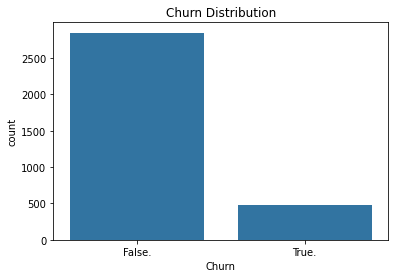

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

### Distribution of Numerical Features
Plot histograms for numerical features to analyze their distributions, skewness, and potential outliers.

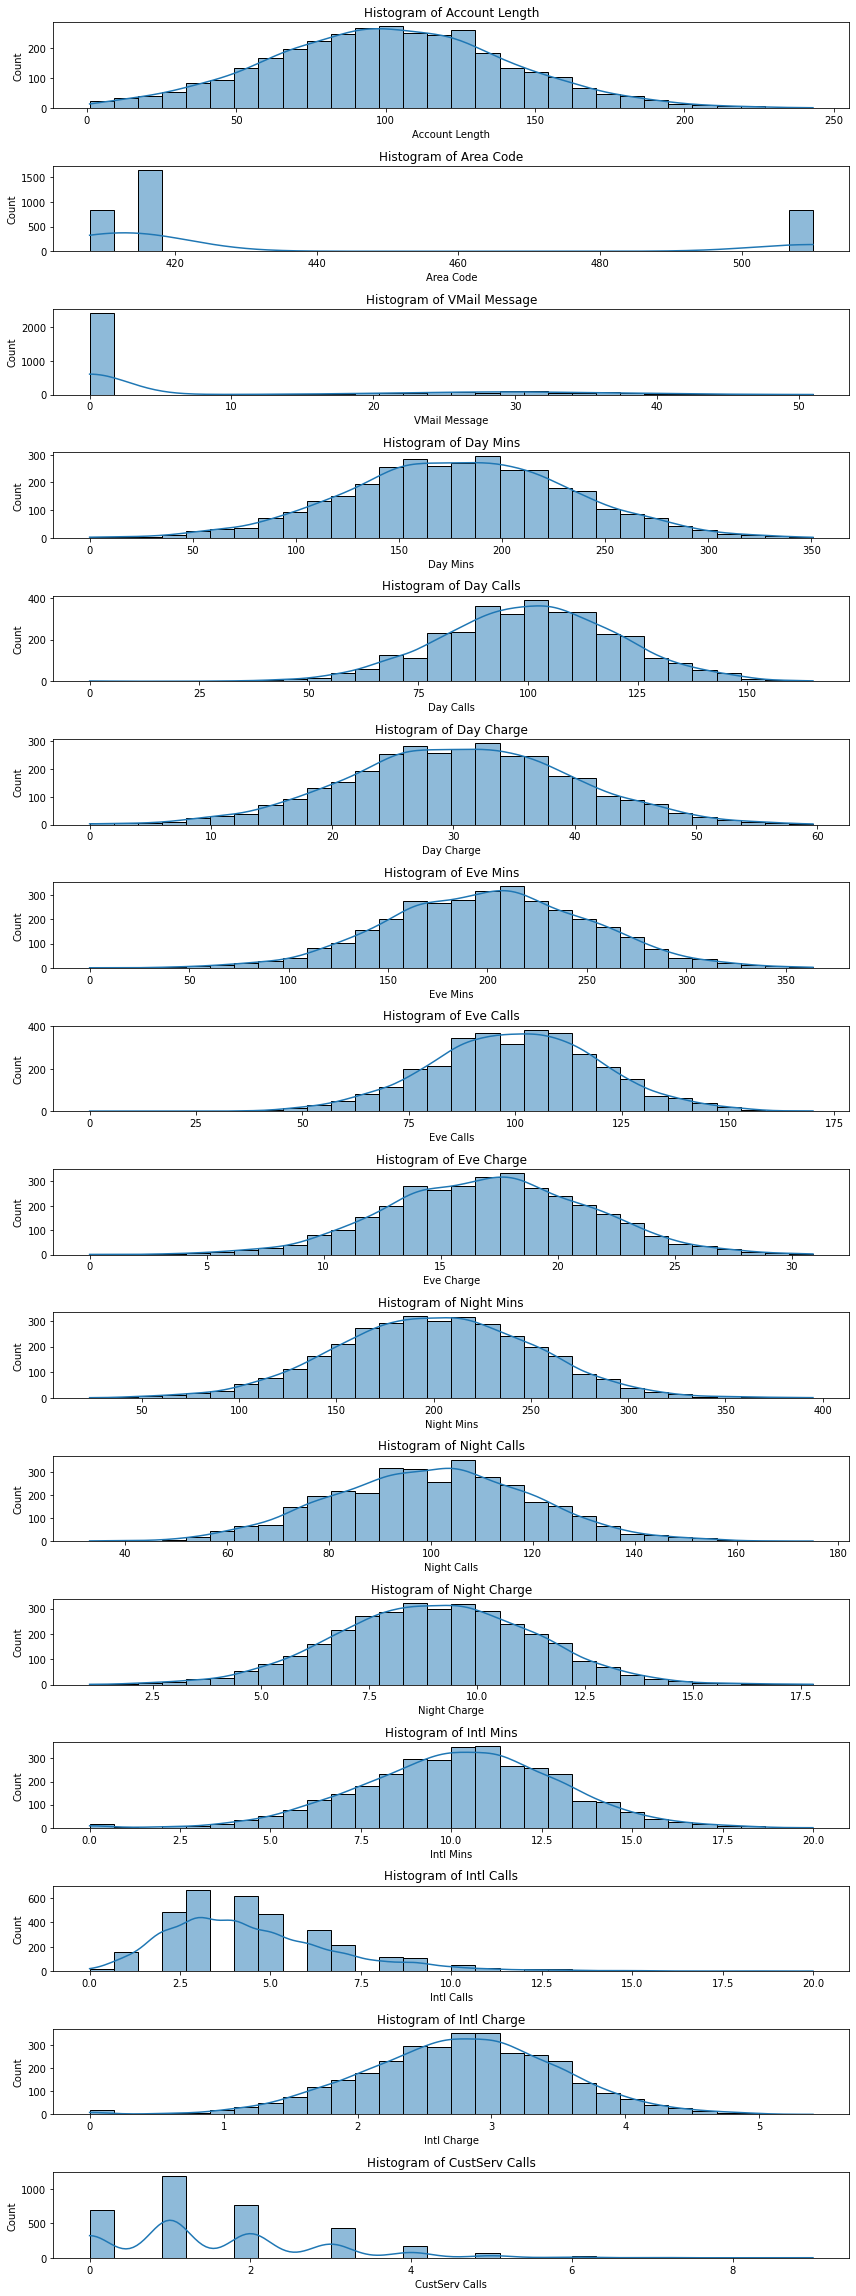

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, len(numeric_cols)*2))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features
Use column graph to illustrate the frequency of each category in categorical variables.

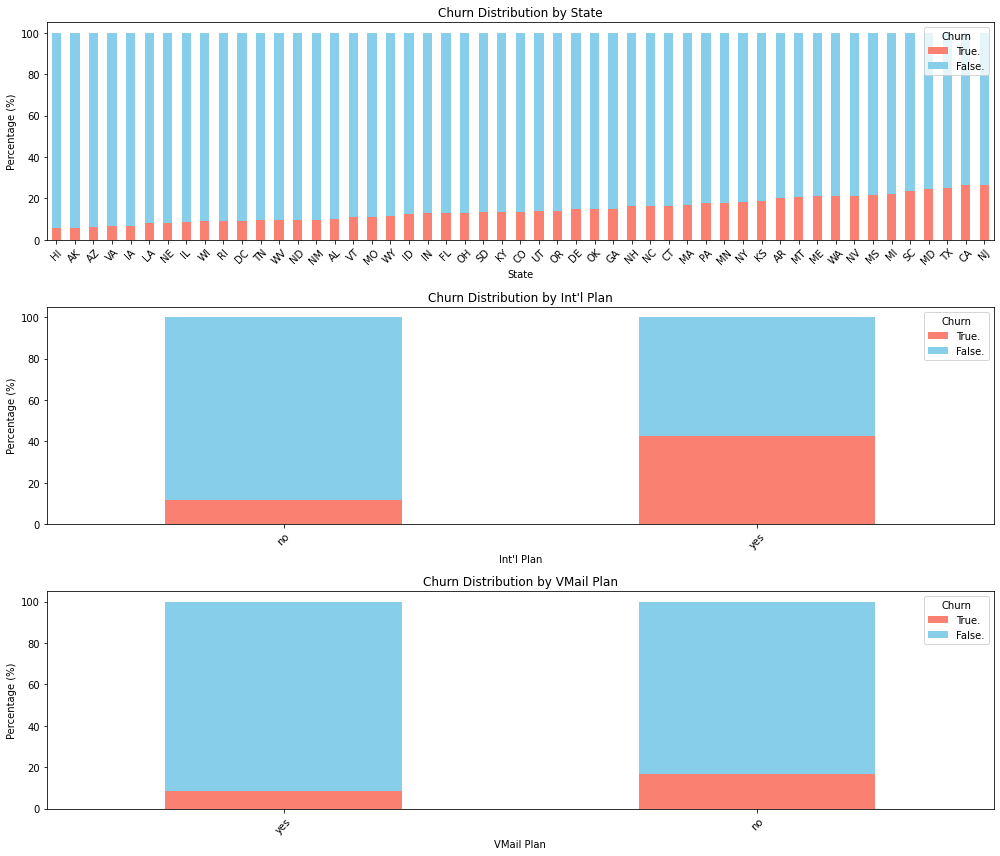

In [9]:
categorical_cols = ['State', "Int'l Plan", 'VMail Plan']

plt.figure(figsize=(14, len(categorical_cols)*4))

for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i+1)

    cross_tab = pd.crosstab(df[col], df['Churn'])
    cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    cross_tab_percent = cross_tab_percent.sort_values(by='True.', ascending=True)
    cross_tab_percent[['True.', 'False.']].plot(
        kind='bar',
        stacked=True,
        ax=plt.gca(),
        color=['salmon', 'skyblue']
    )

    plt.title(f'Churn Distribution by {col}')
    plt.ylabel('Percentage (%)')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(title="Churn", loc='upper right')

plt.tight_layout()
plt.show()

### Correlation Heatmap
Plot a heatmap to visually interpret correlations among numerical features.

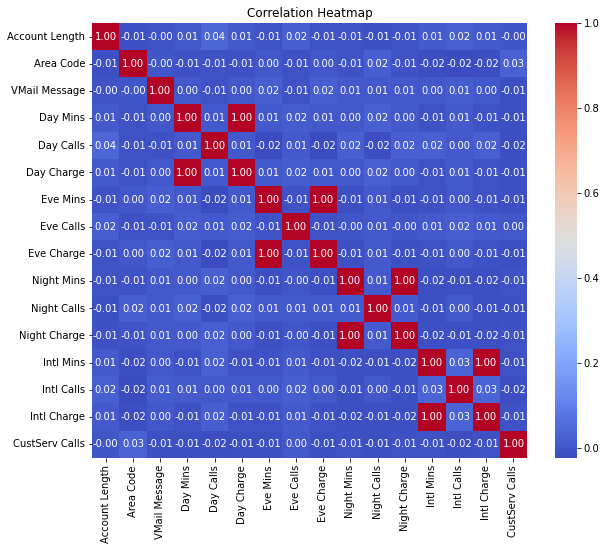

In [10]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()


It is evident that all of daily time charges have strong correlation with their minutes so we could just consider calls either charges for each one

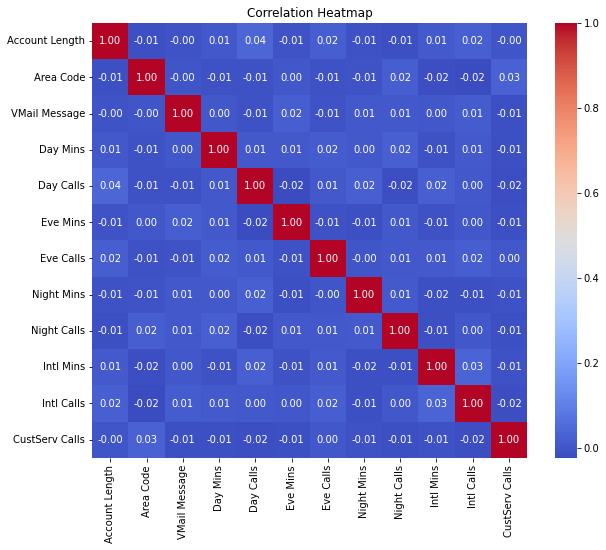

In [11]:
cols_to_drop = [
    'Day Charge',
    'Eve Charge',
    'Night Charge',
    'Intl Charge'
]

df = df.drop(columns=cols_to_drop)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()


### Compare Distributions for Churn vs. Non-Churn
We compare numerical feature distributions between customers who churned and those who did not. This helps identify which features show behavioral differences across the two groups.

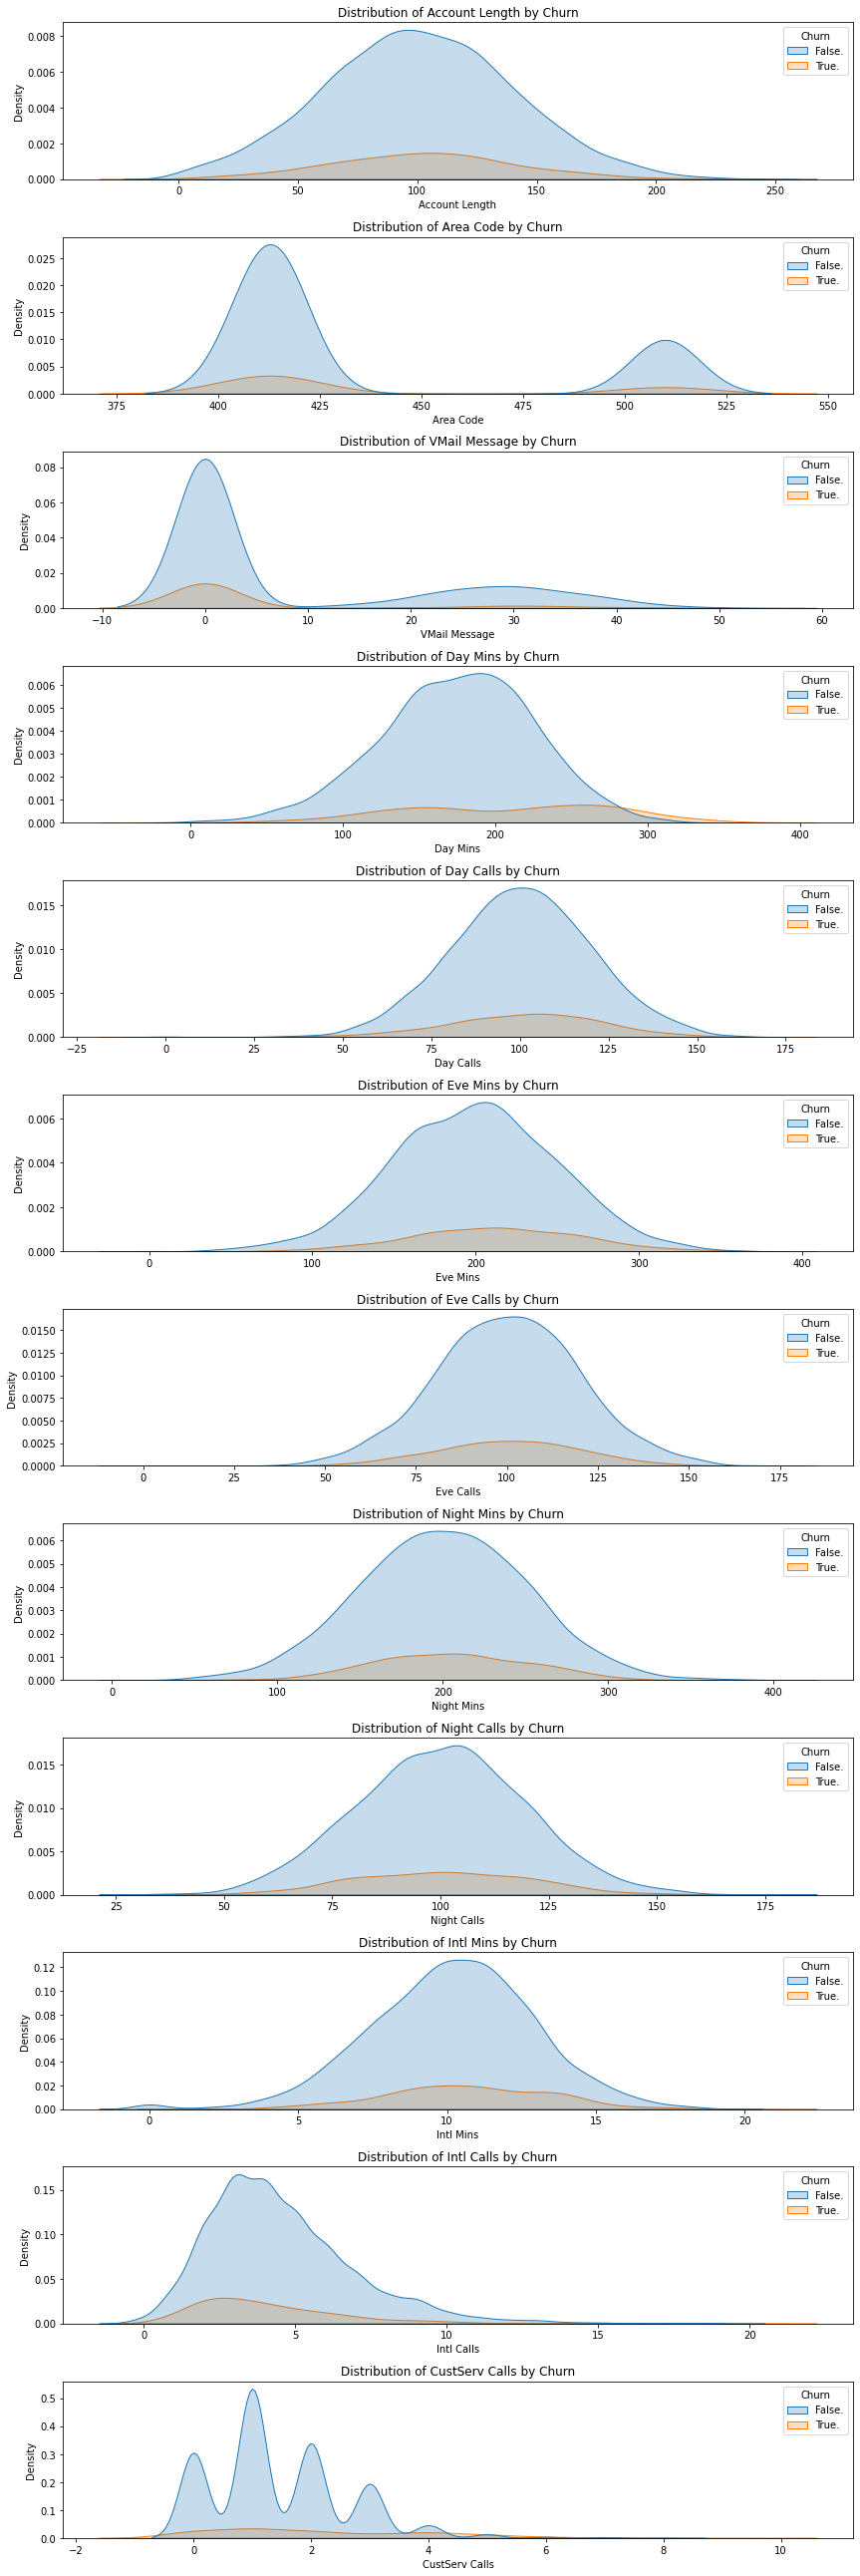

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, len(numeric_cols)*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True)
    plt.title(f"Distribution of {col} by Churn")
plt.tight_layout()
plt.show()

### International Plan vs. Churn
Customers with an international plan may behave differently. Analyzing this relationship helps determine whether subscription features affect churn rates.

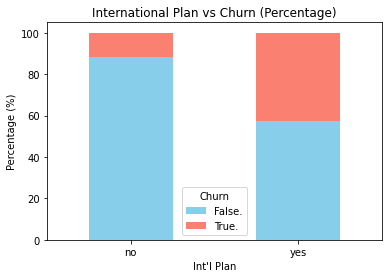

In [13]:
cross_tab = pd.crosstab(df["Int'l Plan"], df["Churn"])
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
cross_tab_percent.plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue','salmon'])

plt.ylabel("Percentage (%)")
plt.title("International Plan vs Churn (Percentage)")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

based on given figure, percentage of people who had international plan and churned were much more higher that others.

therefore, international plan could increase chance of churning.
I think it's due to emigration, and some people who pay for international plan, will never back to US and will use another service company in new target country

### Check Multicollinearity (VIF)
Variance Inflation Factor (VIF) is used to identify multicollinearity among numerical predictors. High VIF values indicate redundant or correlated features.

In [14]:
X = df[numeric_cols].drop(columns=['Churn'], errors='ignore')
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by='VIF')

,feature,VIF
2,VMail Message,1.349878
11,CustServ Calls,2.402062
10,Intl Calls,4.269890
0,Account Length,7.290485
3,Day Mins,11.448382
9,Intl Mins,13.643320
5,Eve Mins,15.600537
7,Night Mins,15.730926
4,Day Calls,23.585228
6,Eve Calls,23.723844


as you can see, Area Code have a very high VIF and it say that it's an redundant feature for predicting churn.

also VMail Message have the minimum VIF and it raises its correlation with churn.

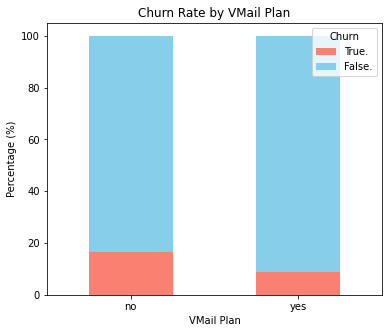

In [15]:
cross_tab = pd.crosstab(df["VMail Plan"], df["Churn"])


cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
cross_tab_percent = cross_tab_percent[['True.','False.']] 

# Plot stacked bar
cross_tab_percent.plot(kind='bar', stacked=True, figsize=(6,5), color=['salmon','skyblue'])

plt.ylabel("Percentage (%)")
plt.xlabel("VMail Plan")
plt.title("Churn Rate by VMail Plan")
plt.xticks(rotation=0)
plt.legend(title="Churn", loc='upper right')
plt.show()

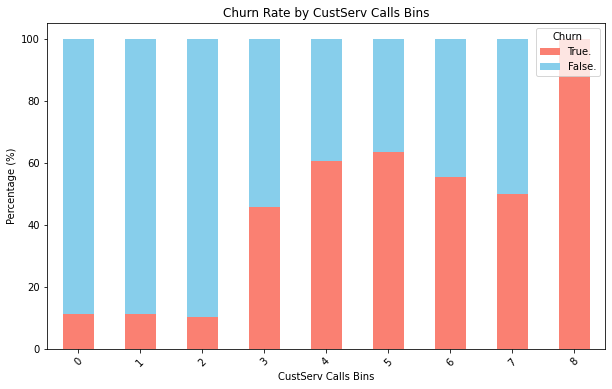

In [16]:
max_calls = df['CustServ Calls'].max()
bins = np.linspace(0, max_calls, 11)
labels = [f"{int(bins[i])}" for i in range(len(bins)-1)]

df['CustServ_Bin'] = pd.cut(
    df['CustServ Calls'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True,
    ordered=False
)



cross_tab = pd.crosstab(df['CustServ_Bin'], df['Churn'])
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
cross_tab_percent = cross_tab_percent[['True.','False.']] 
cross_tab_percent.plot(kind='bar', stacked=True, figsize=(10,6), color=['salmon','skyblue'])

plt.ylabel("Percentage (%)")
plt.xlabel("CustServ Calls Bins")
plt.title("Churn Rate by CustServ Calls Bins")
plt.xticks(rotation=45)
plt.legend(title="Churn", loc='upper right')
plt.show()


we can see that customer service call is also an important factor, if an user have more that 7 calls, then there is a strong possibility to churn for him.

VIF values:
           feature        VIF
1        Area Code  60.934313
8      Night Calls  24.596981
6        Eve Calls  23.723844
4        Day Calls  23.585228
7       Night Mins  15.730926
5         Eve Mins  15.600537
9        Intl Mins  13.643320
3         Day Mins  11.448382
0   Account Length   7.290485
10      Intl Calls   4.269890
11  CustServ Calls   2.402062
2    VMail Message   1.349878
Selected features for PCA: ['Intl Calls', 'CustServ Calls', 'VMail Message']


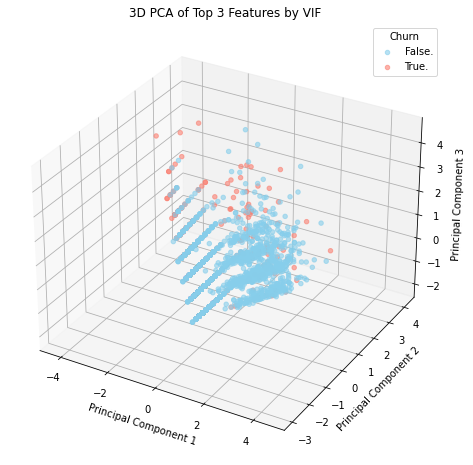

Selected features for PCA: ['Account Length', 'Intl Calls', 'CustServ Calls', 'VMail Message']


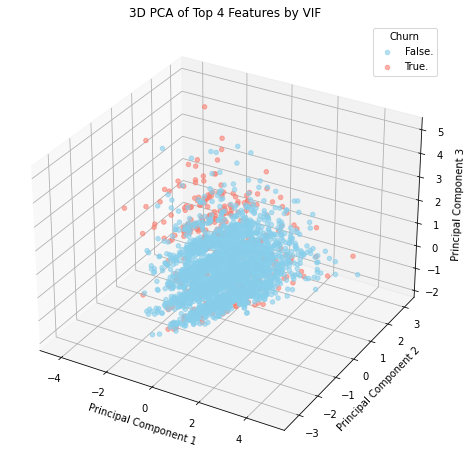

Selected features for PCA: ['Day Mins', 'Account Length', 'Intl Calls', 'CustServ Calls', 'VMail Message']


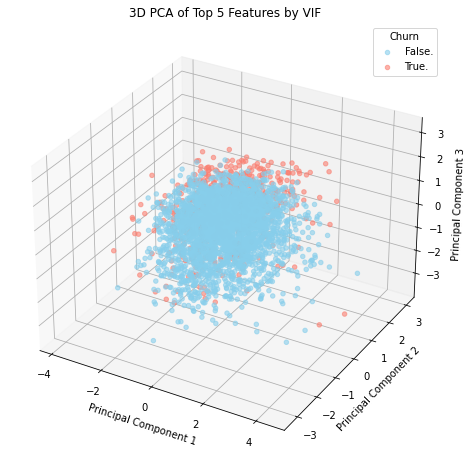

Selected features for PCA: ['Intl Mins', 'Day Mins', 'Account Length', 'Intl Calls', 'CustServ Calls', 'VMail Message']


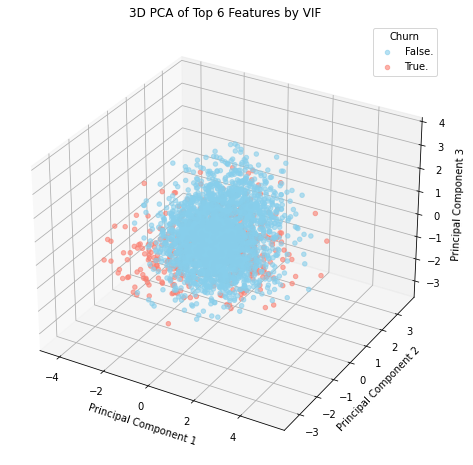

Selected features for PCA: ['Eve Mins', 'Intl Mins', 'Day Mins', 'Account Length', 'Intl Calls', 'CustServ Calls', 'VMail Message']


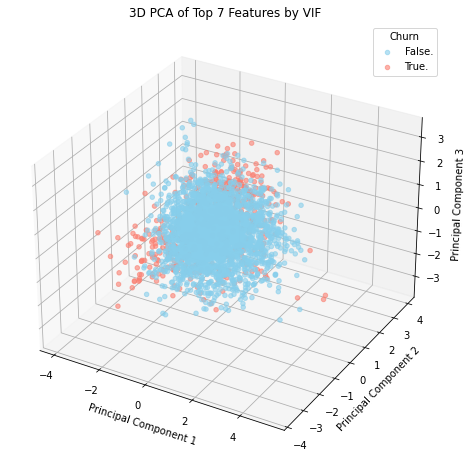

Selected features for PCA: ['Night Mins', 'Eve Mins', 'Intl Mins', 'Day Mins', 'Account Length', 'Intl Calls', 'CustServ Calls', 'VMail Message']


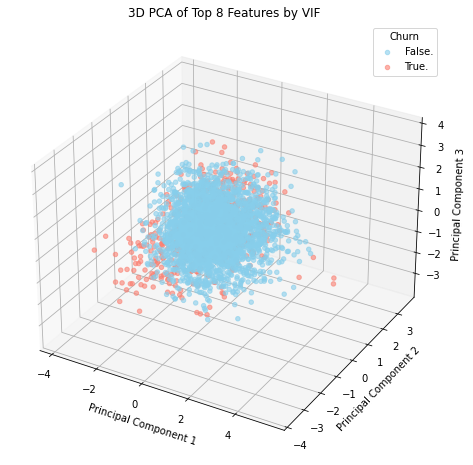

In [17]:
from components import draw_pca_first_n_VIF
    

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute VIF
X = df[numeric_cols].fillna(0)
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_sorted = vif.sort_values(by="VIF", ascending=False)
print("VIF values:")
print(vif_sorted)

# Pick top n features (most important/lowest VIF)
for i in [3,4,5,6,7,8]:
    draw_pca_first_n_VIF(df,vif_sorted,i)
    

When we add features strongly related to churn, the separation between churned and non-churned customers becomes clear in the plot.

But when we add unrelated features, this clear separation disappears. The groups mix together and we can no longer see distinct patterns.

This means our data becomes problematic - good features help us see the difference, while bad features hide it.

In [18]:
from vif_plot import interactive_embedding_explorer

interactive_embedding_explorer(df)

2025-11-23 18:45:35.912681: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


VIF (sorted desc):


,feature,VIF_display
0,Area Code,60.93
1,Night Calls,24.60
2,Eve Calls,23.72
3,Day Calls,23.59
4,Night Mins,15.73
5,Eve Mins,15.60
6,Intl Mins,13.64
7,Day Mins,11.45
8,Account Length,7.29
9,Intl Calls,4.27


Output()

{'ui': HBox(children=(VBox(children=(Dropdown(description='Method:', options=('PCA', 't-SNE', 'UMAP', 'None'), value='PCA'), Dropdown(description='Dims:', options=(2, 3), value=2), HBox(children=(IntSlider(value=30, description='t-SNE perplexity:', min=5), IntSlider(value=15, description='UMAP n_neighbors:', min=2))), HBox(children=(Button(description='Select all', layout=Layout(width='110px'), style=ButtonStyle()), Button(description='Deselect all', layout=Layout(width='110px'), style=ButtonStyle()), Button(button_style='primary', description='Update Plot', layout=Layout(width='140px'), style=ButtonStyle()))))), VBox(children=(Checkbox(value=True, description='Area Code (VIF=60.93)', indent=False), Checkbox(value=True, description='Night Calls (VIF=24.60)', indent=False), Checkbox(value=True, description='Eve Calls (VIF=23.72)', indent=False), Checkbox(value=True, description='Day Calls (VIF=23.59)', indent=False), Checkbox(value=True, description='Night Mins (VIF=15.73)', indent=Fals

## Creating New Features

In [19]:
df['Total Calls'] = df[['Day Calls', 'Eve Calls', 'Night Calls', 'Intl Calls', 'CustServ Calls']].sum(axis=1)
df['Total Mins'] = df[['Day Mins', 'Eve Mins', 'Night Mins', 'Intl Mins']].sum(axis=1)
df['average_activity'] = (df['Day Mins']+df['Eve Mins']+df['Night Mins']) / df['Account Length']
df['day_to_night_ratio'] = df['Day Mins'] / (df['Night Mins'] + 1)
df['eve_to_total_calls'] = df['Eve Calls'] / (df['Total Calls'] + 1)
df['Usage Intensity'] = df['Total Calls'] * df['Total Mins']
df['Call Variability'] = df[['Day Calls', 'Eve Calls', 'Night Calls']].std(axis=1)

The new feature average_activity represents how active each customer is on average during their time with the company. Its VIF score was the lowest, meaning it doesn’t overlap much with other features and may provide unique, meaningful information for predicting churn.

In [20]:
def VIF(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    X = df[numeric_cols].drop(columns=['Churn'], errors='ignore')
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values(by='VIF')


VIF(df)

,feature,VIF
14,average_activity,1.209203
2,VMail Message,1.351806
18,Call Variability,4.656220
0,Account Length,8.170628
15,day_to_night_ratio,31.849708
1,Area Code,105.131443
16,eve_to_total_calls,1429.012846
17,Usage Intensity,1465.234941
7,Night Mins,inf
6,Eve Calls,inf


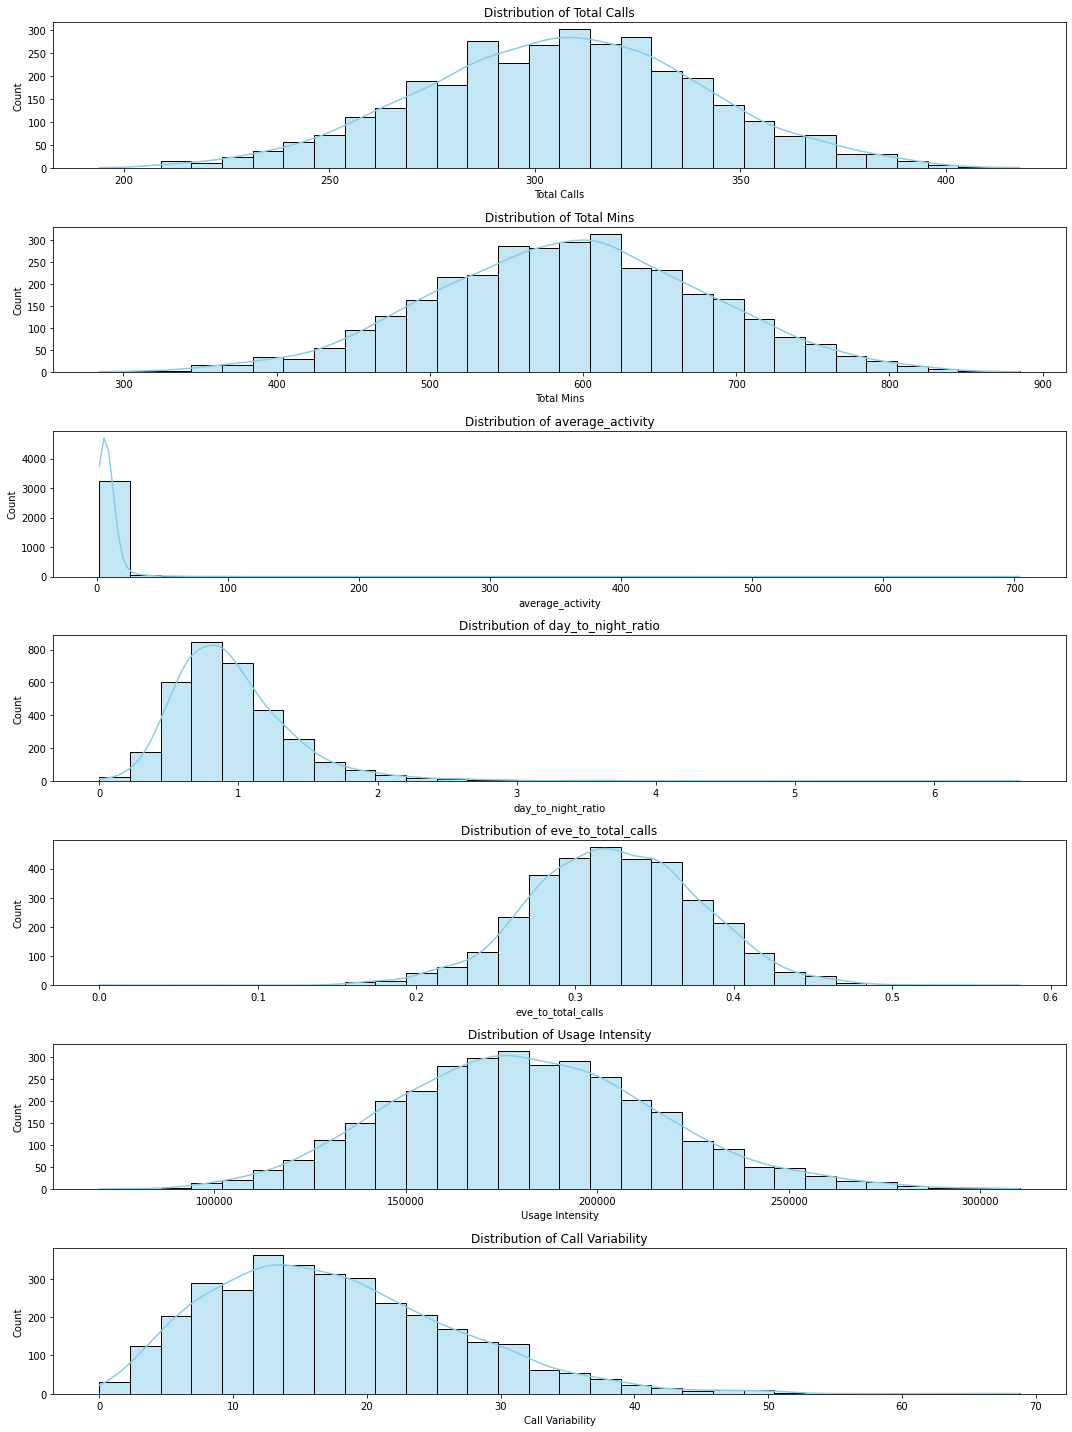

In [21]:
new_features = [
    'Total Calls', 'Total Mins', 'average_activity',
    'day_to_night_ratio', 'eve_to_total_calls',
    'Usage Intensity', 'Call Variability'
]

plt.figure(figsize=(15, 20))

for i, feat in enumerate(new_features):
    plt.subplot(len(new_features), 1, i+1)
    sns.histplot(df[feat], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feat}')
    plt.xlabel(feat)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

We created these new features to better capture customer behavior and usage patterns. However, to understand how useful they really are for predicting churn, we need to test them in our models. In the next steps, we can evaluate their importance and decide which ones to keep or refine further.